### load necessary modules

In [87]:
#env: lpr
# adopted from: https://github.com/StephenChao/boostedHWW/blob/a9dd3a9fe21657d2d103bfb2191271a8894c1865/scale_factors/LundReweighting/calibration_ParT_tagger_H4q3qlvqq.ipynb

In [1]:
import uproot
import awkward as ak
import vector
vector.register_awkward()
from matplotlib import pyplot as plt
import mplhep as hep
hep.style.use("CMS")
import math
import itertools
import os
from typing import Dict, List, Tuple
from numpy.typing import ArrayLike
import numpy as np
import awkward as ak
from coffea.nanoevents.methods import vector
from coffea import nanoevents
from coffea import processor
from coffea.nanoevents.methods import candidate
from coffea.analysis_tools import Weights, PackedSelection
from hist import Hist
ak.behavior.update(vector.behavior)
import sys



In [2]:
MAIN_DIR = "."
sample = "ggF"
data_points = []
year = "2018"
plot_dir = f"{MAIN_DIR}/plots/test_EGM/2Aug2024"
_ = os.system(f"mkdir -p {plot_dir}")

### Load signal NanoAOD files and do pre-selection 

In [12]:
isData = True if sample == "Data" else False
samples = {
    "ggF" : "/data/bond/zhaoyz/Ntuple/EGM_test/merged/ggF/ggF.root",
    "VBF" : "/data/bond/zhaoyz/Ntuple/EGM_test/merged/ggF/VBF.root",
    "Data": "/data/bond/zhaoyz/Ntuple/EGM_test/merged/2018A/2018A.root",
    "QCD" : "/data/bond/zhaoyz/Ntuple/EGM_test/merged/QCD/QCD.root",
    
}
events = nanoevents.NanoEventsFactory.from_root(
        samples[sample],
        schemaclass=nanoevents.NanoAODSchema,
    ).events()

/home/pku/zhaoyz/anaconda3/envs/lpr/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:208: RuntimeWarning: Missing cross-reference target for Electron_photonIdx => Photon
  warnings.warn(
/home/pku/zhaoyz/anaconda3/envs/lpr/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:208: RuntimeWarning: Missing cross-reference target for FatJet_genJetAK8Idx => GenJetAK8
  warnings.warn(
/home/pku/zhaoyz/anaconda3/envs/lpr/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for FsrPhoton_muonIdx => Muon
  warnings.warn(
/home/pku/zhaoyz/anaconda3/envs/lpr/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for GenVisTau_genPartIdxMother => GenPart
  warnings.warn(
/home/pku/zhaoyz/anaconda3/envs/lpr/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:208: RuntimeWarning: Missing cross-reference target for Jet_genJetIdx => GenJet

In [13]:
if isData == True:
    desired_fields = ["Electron","Muon","FatJet"]
else: 
    desired_fields = ["Electron","Muon","FatJet","genWeight","GenPart"]
filtered_events = events[desired_fields]

### Define necessary functions to run the selection

In [5]:
#pad array with given value
def pad_val(
    arr: ak.Array,
    target: int,
    value: float, #value can also be Bool variable 
    axis: int = 0,
    to_numpy: bool = True,
    clip: bool = True,
):
    """
    pads awkward array up to ``target`` index along axis ``axis`` with value ``value``,
    optionally converts to numpy array
    """
    padded_arr = ak.fill_none(ak.pad_none(arr, target, axis=axis, clip=clip), value, axis=axis)
    # pad_none will fill the array to target length with "None" for dedicated axis
    # "clip" means cut the array to the target length or not
    # fill_none will replace "None" value to some value
    return padded_arr.to_numpy() if to_numpy else padded_arr

def add_selection(
    name: str,
    sel: np.ndarray,
    selection: PackedSelection,
    cutflow: dict = None,
    isData: bool = False,
    signGenWeights: ak.Array = None,
):
    """adds selection to PackedSelection object and the cutflow dictionary"""
    selection.add(name, sel)
    if cutflow is not None: #only add to cutflow dictionary if cutflow is not None
        cutflow[name] = (
            np.sum(selection.all(*selection.names))
            if isData
            # add up sign of genWeights for MC
            else np.sum(signGenWeights[selection.all(*selection.names)])
        )


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

def flow(hist: bh.Histogram, overflow: bool=False, underflow: bool=False):
    h, var = hist.view(flow=(overflow | underflow)).value, hist.view(flow=(overflow | underflow)).variance
    if overflow: 
        # h, var also include underflow bins but in plots usually no underflow data
        # And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
        # You have to access the overflow and underflow bins data like below:
        h[-2] += h[-1]; var[-2] += var[-1]
    if underflow:
        h[1] += h[0]; var[1] += var[0]
    if overflow or underflow:
        h, var = h[1:-1], var[1:-1]
    return h, var
    # Return the updated histogram and variance

def error_bar(h, var, type='data'):
    from scipy.interpolate import CubicSpline
    if type == 'data':
        number = h
    elif type == 'mc':  # h = k*N, var = k^2*N, std = k*sqrt(N)
        number = h**2 / var
    else:
        raise ValueError("type should be 'data' or 'mc'! ")
    center = range(11) # Number: 0-10
    up = np.array([1.84, 3.30, 4.64, 5.92, 7.16, 8.38, 9.58, 10.77, 11.95, 13.11, 14.27]) - center
    down = center - np.array([0, 0.17, 0.71, 1.37, 2.09, 2.84, 3.62, 4.42, 5.23, 6.06, 6.89])
    #cs means to create a CubicSpline object
    cs_up = CubicSpline(x=center, y=up)
    cs_down = CubicSpline(x=center, y=down)
    
    Garwood = (number>0)&(number<10)
    poison_error_bar = np.sqrt(number)
    up_error_bar = np.copy(poison_error_bar)
    down_error_bar = np.copy(poison_error_bar)
    up_error_bar[Garwood] = cs_up(number[Garwood])
    down_error_bar[Garwood] = cs_down(number[Garwood])
    if type == 'mc':
        up_error_bar *= var/h
        down_error_bar *= var/h
    up_error_bar [up_error_bar < 0 ] = 0
    down_error_bar [down_error_bar < 0 ] = 0
    return np.array([down_error_bar, up_error_bar])

### Kinematic cut

In [14]:
#pre-selection:
#1.Leading jet pT > 400GeV, maximum jet mass > 50GeV
#2.Require 2 or 3 AK8 jet with pT > 200GeV
#3.Veto (mini-)Isolated leptons
signGenWeights = None if isData else np.sign(filtered_events["genWeight"]) #get genWeight sign, because only the sign matters
n_events = len(filtered_events) if isData else int(np.sum(signGenWeights)) #events number for MC events should be the sum of "sign"
selection = PackedSelection() #initialize a new object

cutflow = {}
# cutflow["all"] = len(events) #shouldn't be n_events?
cutflow["all"] = n_events
preselection_cut_vals = {"pt": 200, "msd": 20, "leading_pt":400,"maximum_mass":50}
num_jets = 2

# fatjets = corrections.get_jec_jets(events, "2018")
fatjets = filtered_events.FatJet

preselection_cut_1 = pad_val(
        ( ak.max(filtered_events.FatJet.pt, axis = 1) > preselection_cut_vals["leading_pt"])
        * (ak.max(filtered_events.FatJet.msoftdrop, axis = 1) > preselection_cut_vals["maximum_mass"]), #mass and pT cut of each jet in event
        len(events), #pad to num_jets length
        False,  #pad with value False
        )
# finally with the length of events number, "1" for all jets are pT > pT_cut and mass > mass_cut
 # N.B. here clip always = True

add_selection(
    "leading pT and maximum mass", #string name
    preselection_cut_1.astype(bool), #selection content
    selection, #PackedSelection object
    cutflow, #cut-flow dict, storing events number after each cut
    isData,
    signGenWeights,#sum the signGenWeights for events which pass the selection
)



preselection_cut_2 = np.prod(
    pad_val(
        (filtered_events.FatJet.pt > preselection_cut_vals["pt"]),
        # * (events.FatJet.msoftdrop > preselection_cut_vals["msd"]), #mass and pT cut of each jet in event
        num_jets, #pad to num_jets length
        False,  #pad with value False
        axis=1, #pad to axis=1
    ),
    axis=1,
)# finally with the length of events number, "1" for all jets are pT > pT_cut and mass > mass_cut
 # N.B. here clip always = True

add_selection(
    "at least 2 AK8 jet with pT >200GeV", #string name
    preselection_cut_2.astype(bool), #selection content
    selection, #PackedSelection object
    cutflow, #cut-flow dict, storing events number after each cut
    isData,
    signGenWeights,#sum the signGenWeights for events which pass the selection
)

preselection_cut_3 = pad_val(
        (ak.num(filtered_events.FatJet.pt) == 2) | (ak.num(filtered_events.FatJet.pt) == 3) , #mass and pT cut of each jet in event
        len(filtered_events), #pad to num_jets length
        False,  #pad with value False
        )

add_selection(
    "2 or 3 AK8 jet", #string name
    preselection_cut_3.astype(bool), #selection content
    selection, #PackedSelection object
    cutflow, #cut-flow dict, storing events number after each cut
    isData,
    signGenWeights,#sum the signGenWeights for events which pass the selection
)


In [15]:
cutflow

{'all': 31075,
 'leading pT and maximum mass': 29950.0,
 'at least 2 AK8 jet with pT >200GeV': 29948.0,
 '2 or 3 AK8 jet': 29184.0}

In [16]:
# derive events after the kinematic selection
filtered_events = filtered_events[selection.all(*selection.names)]

In [17]:
filtered_events.fields

['Electron', 'Muon', 'FatJet', 'genWeight', 'GenPart']

### Determine the fraction of 1e and 0e events before the veto

In [18]:
# First determine the P_0 and P_1 as EGM contact suggested here:
# https://cms-pub-talk.web.cern.ch/t/hig-23-008-boosted-h-ww-hadronic-part-hig-egm-review/24750/10
# use gen-level lepton number from HWW decay

d_PDGID = 1
b_PDGID = 5
g_PDGID = 21
TOP_PDGID = 6

ELE_PDGID = 11
vELE_PDGID = 12
MU_PDGID = 13
vMU_PDGID = 14
TAU_PDGID = 15
vTAU_PDGID = 16

Z_PDGID = 23
W_PDGID = 24
HIGGS_PDGID = 25

b_PDGIDS = [511, 521, 523]

GRAV_PDGID = 39

GEN_FLAGS = ["fromHardProcess", "isLastCopy"]

FILL_NONE_VALUE = -99999


skim_vars = {
    "eta": "eta",
    "phi": "phi",
    "mass": "mass",
    "pt": "pt",
}

# finding the gen Higgs
higgs = filtered_events.GenPart[
    (abs(filtered_events.GenPart.pdgId) == HIGGS_PDGID) * filtered_events.GenPart.hasFlags(GEN_FLAGS)
]

In [20]:
# check how many semi-leptonic decay and hadronic decay Higgs:
higgs_children = higgs.distinctChildren
higgs_children = higgs_children[higgs_children.hasFlags(GEN_FLAGS)]
ws = ak.flatten(higgs_children[np.abs(higgs_children.pdgId) == W_PDGID], axis=2)
had_higgs_sel = np.all(np.abs(ws.children.pdgId) <= 5, axis=2)

In [26]:
len(had_higgs_sel)

29194

In [27]:
n_full_had = np.sum(np.all(had_higgs_sel,axis = 1))

In [28]:
n_full_had

20187

In [30]:
n_semi_lep = len(had_higgs_sel) - n_full_had
n_semi_lep

9007

### now that we want to check the fraction in SRs, need to do tagger cut

In [31]:
#compute tagger score
eventsScoreFatjet = filtered_events
tagger_scores = eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWev0c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWev1c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWmv0c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWmv1c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWq0c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWq1c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWq2c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWqq0c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWqq1c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWqq2c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWtauev0c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWtauev1c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWtauhv0c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWtauhv1c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWtaumv0c + eventsScoreFatjet.FatJet.inclParTMDV1_probHWqqWtaumv1c
leading_tagger = np.max(tagger_scores,axis = 1) #leading tagger score

#define selection
selection = PackedSelection() #initialize a new object
signGenWeights = None if isData else np.sign(filtered_events["genWeight"]) #get genWeight sign, because only the sign matters
n_events = len(filtered_events) if isData else int(np.sum(signGenWeights)) #events number for MC events should be the sum of "sign"
selection = PackedSelection() #initialize a new object
cutflow = {}
# cutflow[\"all\"] = len(events) #shouldn't be n_events?
cutflow["all"] = n_events
preselection_cut_tag = pad_val(
        (leading_tagger >= 0.92) , #mass and pT cut of each jet in event
        len(filtered_events), #pad to num_jets length
        False,  #pad with value False
        )
add_selection(
    "tagger cut", #string name
    preselection_cut_tag.astype(bool), #selection content
    selection, #PackedSelection object
    cutflow, #cut-flow dict, storing events number after each cut
    isData,
    signGenWeights,#sum the signGenWeights for events which pass the selection
)



In [32]:
cutflow

{'all': 29184, 'tagger cut': 6443.0}

In [33]:
filtered_events = filtered_events[selection.all(*selection.names)]

### do check for gen-electron number

### Determine the fraction of 1e and 0e events before the veto

In [34]:
# First determine the P_0 and P_1 as EGM contact suggested here:
# https://cms-pub-talk.web.cern.ch/t/hig-23-008-boosted-h-ww-hadronic-part-hig-egm-review/24750/10
# use gen-level lepton number from HWW decay

d_PDGID = 1
b_PDGID = 5
g_PDGID = 21
TOP_PDGID = 6

ELE_PDGID = 11
vELE_PDGID = 12
MU_PDGID = 13
vMU_PDGID = 14
TAU_PDGID = 15
vTAU_PDGID = 16

Z_PDGID = 23
W_PDGID = 24
HIGGS_PDGID = 25

b_PDGIDS = [511, 521, 523]

GRAV_PDGID = 39

GEN_FLAGS = ["fromHardProcess", "isLastCopy"]

FILL_NONE_VALUE = -99999


skim_vars = {
    "eta": "eta",
    "phi": "phi",
    "mass": "mass",
    "pt": "pt",
}

# finding the gen Higgs
higgs = filtered_events.GenPart[
    (abs(filtered_events.GenPart.pdgId) == HIGGS_PDGID) * filtered_events.GenPart.hasFlags(GEN_FLAGS)
]

In [35]:
# check how many semi-leptonic decay and hadronic decay Higgs:
higgs_children = higgs.distinctChildren
higgs_children = higgs_children[higgs_children.hasFlags(GEN_FLAGS)]
ws = ak.flatten(higgs_children[np.abs(higgs_children.pdgId) == W_PDGID], axis=2)
had_higgs_sel = np.all(np.abs(ws.children.pdgId) <= 5, axis=2)

In [36]:
len(had_higgs_sel)

6447

In [37]:
n_full_had = np.sum(np.all(had_higgs_sel,axis = 1))

In [38]:
n_full_had

3140

In [39]:
n_semi_lep = len(had_higgs_sel) - n_full_had
n_semi_lep

3307

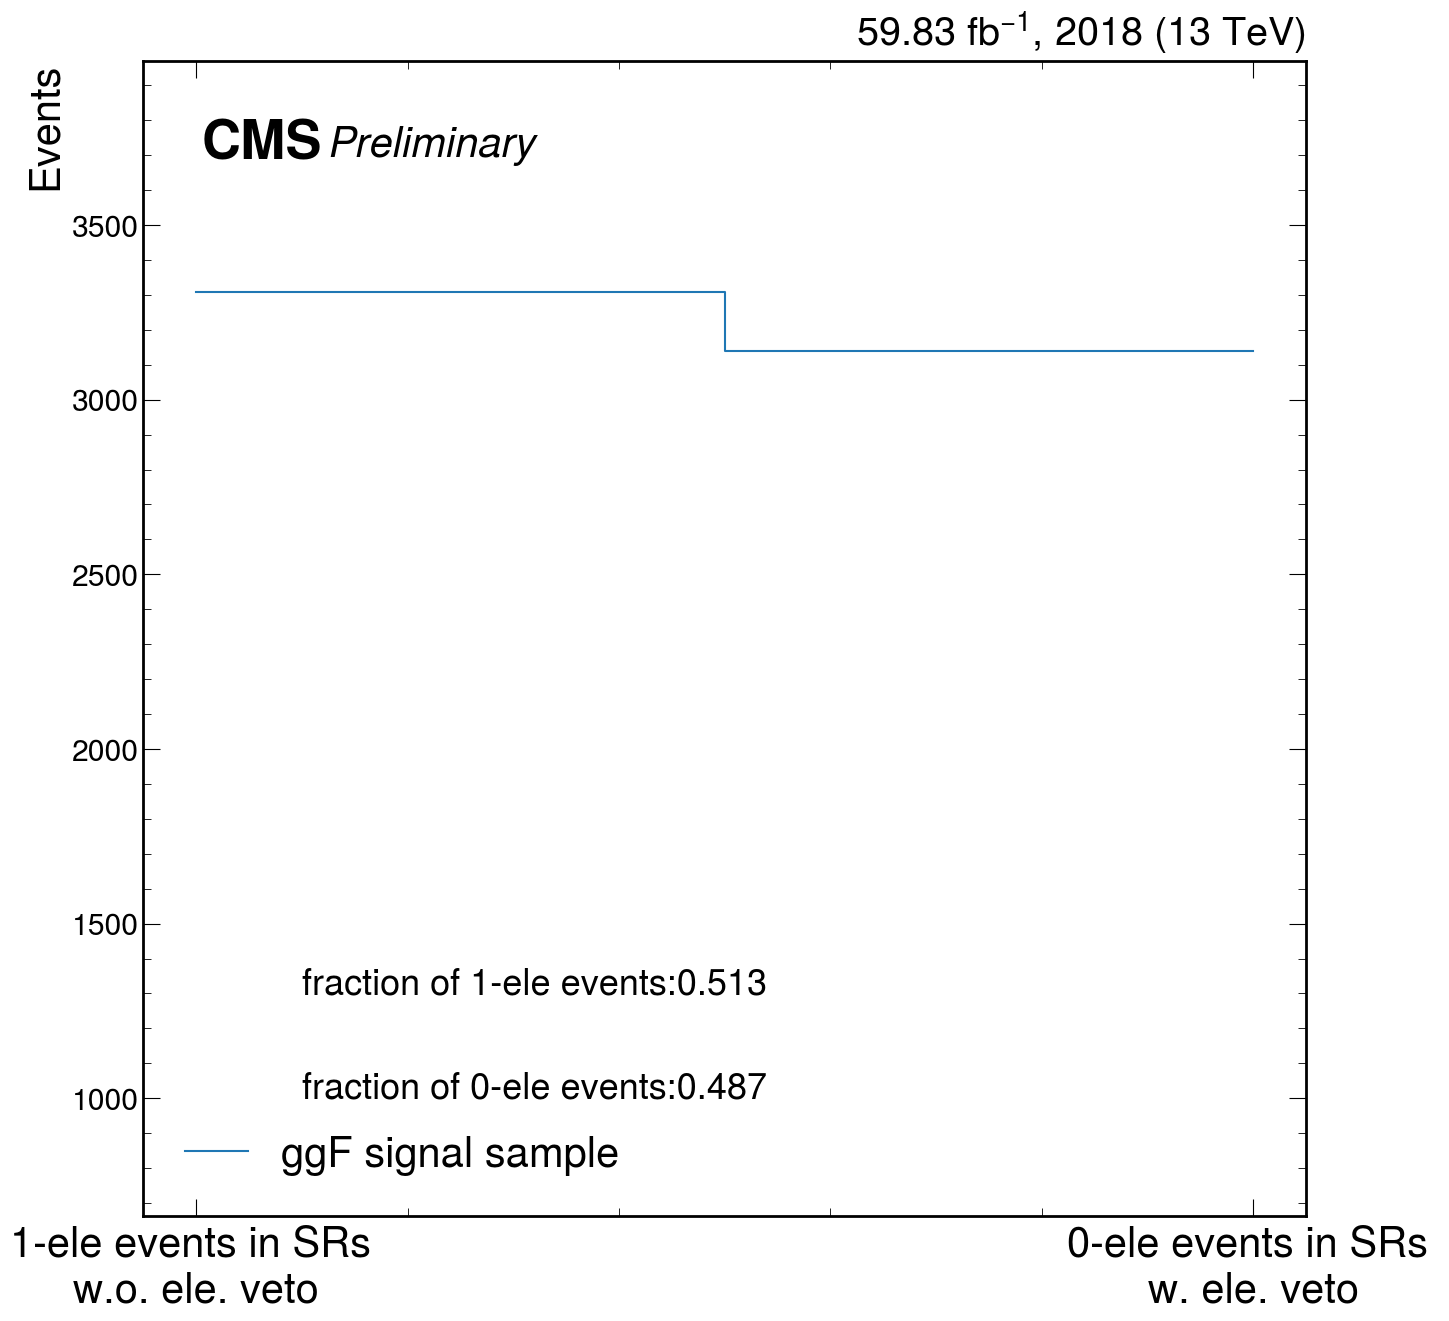

In [50]:
### plot the n_semi_lep and n_full_had to show the fraction of each:

import matplotlib.pyplot as plt
import mplhep as hep

# 数据点和标签
labels = ['1-ele events in SRs \nw.o. ele. veto', "0-ele events in SRs \nw. ele. veto"]


# 创建阶梯状图
LUMI = {"2016": 36.33, "2017": 41.48, "2018": 59.83,"Full-Run2":138}
fig, ax = plt.subplots(figsize = (15,15))
ax.step(range(2), [n_semi_lep,n_full_had], where='mid', label=f"{sample} signal sample")
# ax.step(range(len(data_points)), data_points, where='mid')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize = 30)
hep.cms.label(loc = 1, data=isData, year=year, ax=ax, lumi=LUMI[year], fontsize=30, llabel='Preliminary')

ax.text(0.1,1300,"fraction of 1-ele events:%.3f"%((n_semi_lep/(n_semi_lep + n_full_had))))
ax.text(0.1,1000,"fraction of 0-ele events:%.3f"%((n_full_had/(n_semi_lep + n_full_had))))
# 添加标签和标题
# ax.set_xlabel('Labels')
ax.set_ylim(n_semi_lep*0.2,n_semi_lep*1.2)
ax.set_ylabel('Events',fontsize = 30)
# ax.set_title('Events number after each cut',fontsize = 30)
ax.legend(loc = "lower left",fontsize = 30)

# 如果你想使用HEP样式
hep.style.use("CMS")
plt.savefig(f"{plot_dir}/{sample}.pdf")
# 显示图形
plt.show()


### Compute C

In [53]:
C = (0.487 + 0.513*(1-0.98))/(0.487 + 0.513*(1-0.77))

In [54]:
C

0.8219309410072893

### cut

In [100]:
#define good/loose electron, but without pT selection because we want to see the pT distribution
electrons = filtered_events.Electron

loose_electrons_wo_pt = (
    (np.abs(electrons.eta) < 2.5)
    & ((np.abs(electrons.eta) < 1.44) | (np.abs(electrons.eta) > 1.57))
    # & (electrons.cutBased >= 2)
    & (electrons.mvaFall17V2noIso_WPL)
    # & (electrons.cutBased >= electrons.LOOSE) #cut-based ID Fall17 V2 (0:fail, 1:veto, 2:loose, 3:medium, 4:tight)
)

good_electrons_wo_pt = (
    (np.abs(electrons.eta) < 2.5)
    & ((np.abs(electrons.eta) < 1.44) | (np.abs(electrons.eta) > 1.57))
    & (np.abs(electrons.dz) < 0.1)
    & (np.abs(electrons.dxy) < 0.05)
    & (electrons.sip3d <= 4.0)
    & (electrons.mvaFall17V2noIso_WP90)
)

In [101]:
good_ele_pt_unflt = electrons[good_electrons_wo_pt].pt
good_ele_pt = ak.flatten(good_ele_pt_unflt[ak.num(good_ele_pt_unflt, axis = 1) > 0], axis= 1)

loose_ele_pt_unflt = electrons[loose_electrons_wo_pt].pt
loose_ele_pt = ak.flatten(loose_ele_pt_unflt[ak.num(loose_ele_pt_unflt, axis = 1) > 0], axis= 1)

### good ele

In [102]:
# get loose efficiency distribution
efficiency_good = []
for pT_cut in range(0,100,4):
    print("pT_cut:", pT_cut)
    cut_arr = ((electrons.pt >= pT_cut) & (electrons.pfRelIso03_all < 0.15)) | (electrons.pt >= 120)
    complete_good_ele = (cut_arr & good_electrons_wo_pt) #pT cut * definition discarding pT cut
    num_complete_good_ele = ak.sum(complete_good_ele, axis = 1)
    #num = events number after veto, denom = total event numer
    efficiency_i = (len(num_complete_good_ele) - ak.sum(num_complete_good_ele != 0))/len(num_complete_good_ele)
    efficiency_good.append(efficiency_i)
    print("efficiency:",efficiency_i)
efficiency_good = ak.Array(efficiency_good)

pT_cut: 0
efficiency: 0.9826749826749827
pT_cut: 4
efficiency: 0.9826749826749827
pT_cut: 8
efficiency: 0.9829059829059829
pT_cut: 12
efficiency: 0.9831369831369832
pT_cut: 16
efficiency: 0.9831369831369832
pT_cut: 20
efficiency: 0.9840609840609841
pT_cut: 24
efficiency: 0.9845229845229845
pT_cut: 28
efficiency: 0.9847539847539848
pT_cut: 32
efficiency: 0.9852159852159852
pT_cut: 36
efficiency: 0.9856779856779857
pT_cut: 40
efficiency: 0.9863709863709864
pT_cut: 44
efficiency: 0.9863709863709864
pT_cut: 48
efficiency: 0.9866019866019866
pT_cut: 52
efficiency: 0.9866019866019866
pT_cut: 56
efficiency: 0.9868329868329868
pT_cut: 60
efficiency: 0.9872949872949873
pT_cut: 64
efficiency: 0.9875259875259875
pT_cut: 68
efficiency: 0.9884499884499884
pT_cut: 72
efficiency: 0.988911988911989
pT_cut: 76
efficiency: 0.9891429891429891
pT_cut: 80
efficiency: 0.9896049896049897
pT_cut: 84
efficiency: 0.9898359898359899
pT_cut: 88
efficiency: 0.9900669900669901
pT_cut: 92
efficiency: 0.9900669900669

/tmp/ipykernel_1863380/2515325790.py:34: RuntimeWarning: invalid value encountered in true_divide
  number = h**2 / var
/tmp/ipykernel_1863380/2515325790.py:51: RuntimeWarning: invalid value encountered in true_divide
  up_error_bar *= var/h
/tmp/ipykernel_1863380/2515325790.py:52: RuntimeWarning: invalid value encountered in true_divide
  down_error_bar *= var/h


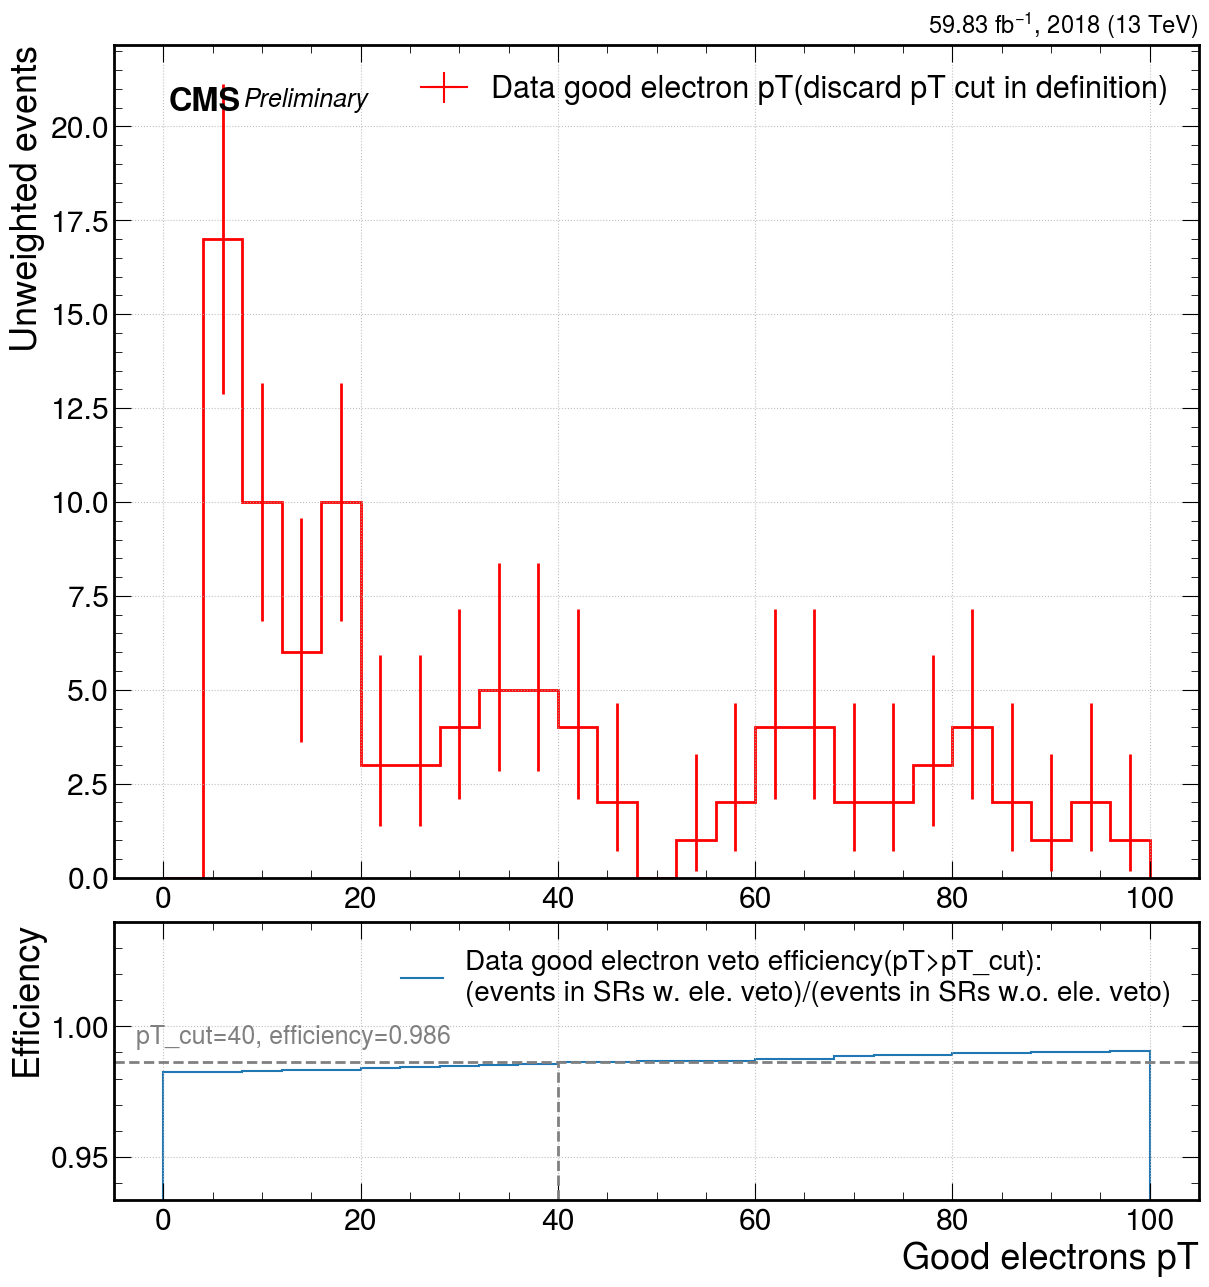

In [103]:
# plot good ele distribution
nbins = 25
x_min = 0
x_max = 100
legend_location='upper left'
plt.rcParams['axes.prop_cycle'] = cycler(color=["tab:blue",	"tab:orange",	"tab:green",	"tab:red",	"tab:purple", "tab:brown", "tab:pink", "k","tab:olive" ,	"tab:cyan"])
# plt.figure(figsize=(14,10))
f = plt.figure(figsize=(14, 15))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax = f.add_subplot(gs[0])
plt.grid()
LUMI = {"2016": 36.33, "2017": 41.48, "2018": 59.83,"Full-Run2":138}
hep.cms.label(loc = 1, data=True, year=year, ax=ax, lumi=LUMI[year], fontsize=18, llabel='Preliminary')
ax1 = f.add_subplot(gs[1])
ax1.grid()

#plot pT distribution first
hist_region = bh.Histogram(bh.axis.Regular(nbins, x_min, x_max), storage=bh.storage.Weight())
hist_region.fill(good_ele_pt)
hist_value_up = flow(hist_region)[0]
hist_var_up   = flow(hist_region)[1]
err_up = np.nan_to_num(error_bar(hist_value_up, hist_var_up, type = "mc"), nan = 0)
hep.histplot(hist_value_up, bins=hist_region.axes[0].edges, yerr=err_up, label=f"{sample} good electron pT(discard pT cut in definition)", histtype='step', stack=False, linewidth=2, ax=ax, color = "red")

#then plot pT cut efficiency
hep.histplot(efficiency_good, bins=hist_region.axes[0].edges,ax = ax1, label=f"{sample} good electron veto efficiency(pT>pT_cut):\n(events in SRs w. ele. veto)/(events in SRs w.o. ele. veto)")

ax1.plot([40,40],[0.95*ak.min(efficiency_good), efficiency_good[10]], linestyle="dashed", lw=2, color='gray')
# ax1.plot([ax1.get_xlim()[0],ax1.get_xlim()[1]], [efficiency_good[10],efficiency_good[10]], linestyle="dashed", lw=2, color='gray')    
ax1.axhline(y=efficiency_good[10], xmin=0, xmax=1, linestyle="dashed", lw=2, color='gray')
# ax.set_xlabel("Good electrons pT")
ax.set_ylabel("Unweighted events")

ax1.set_xlabel("Good electrons pT")
ax1.set_ylabel("Efficiency")
ax1.text(0.02,-0.2,f"pT_cut=40, efficiency={str(round(efficiency_good[10],3))}",fontsize=18, color="gray", ha='left',transform=ax.transAxes)
# (efficiency_good[10]/100)*0.5
ax1.set_ylim(0.95*ak.min(efficiency_good), 1.05*ak.max(efficiency_good))
# ax.set_yscale('log') 
ax.legend(loc="upper right", ncol=1, frameon=False, fontsize=22)
ax1.legend(loc="upper right", ncol=1, frameon=False, fontsize=20)

plt.savefig(f"{plot_dir}/good_ele_pT_{year}_{sample}.pdf", bbox_inches='tight')    


### loose ele

In [104]:
# get loose efficiency distribution
efficiency_loose = []
for pT_cut in range(0,100,4):
    print("pT_cut:", pT_cut)
    cut_arr = ((electrons.pt >= pT_cut) & (electrons.pfRelIso03_all < 0.25)) | (electrons.pt >= 120)
    complete_loose_ele = (cut_arr & loose_electrons_wo_pt) #pT cut * definition discarding pT cut
    num_complete_loose_ele = ak.sum(complete_loose_ele, axis = 1)
    #num = events number after veto, denom = total event numer
    efficiency_i = (len(num_complete_loose_ele) - ak.sum(num_complete_loose_ele != 0))/len(num_complete_loose_ele)
    efficiency_loose.append(efficiency_i)
    print("efficiency:",efficiency_i)
efficiency_loose = ak.Array(efficiency_loose)

pT_cut: 0
efficiency: 0.9581889581889582
pT_cut: 4
efficiency: 0.9581889581889582
pT_cut: 8
efficiency: 0.9595749595749595
pT_cut: 12
efficiency: 0.9598059598059598
pT_cut: 16
efficiency: 0.9604989604989606
pT_cut: 20
efficiency: 0.9621159621159621
pT_cut: 24
efficiency: 0.9632709632709633
pT_cut: 28
efficiency: 0.963963963963964
pT_cut: 32
efficiency: 0.966042966042966
pT_cut: 36
efficiency: 0.9665049665049665
pT_cut: 40
efficiency: 0.9676599676599676
pT_cut: 44
efficiency: 0.9676599676599676
pT_cut: 48
efficiency: 0.9688149688149689
pT_cut: 52
efficiency: 0.9688149688149689
pT_cut: 56
efficiency: 0.9692769692769693
pT_cut: 60
efficiency: 0.9704319704319704
pT_cut: 64
efficiency: 0.9708939708939709
pT_cut: 68
efficiency: 0.9718179718179718
pT_cut: 72
efficiency: 0.9727419727419727
pT_cut: 76
efficiency: 0.9734349734349734
pT_cut: 80
efficiency: 0.9743589743589743
pT_cut: 84
efficiency: 0.9748209748209749
pT_cut: 88
efficiency: 0.9752829752829753
pT_cut: 92
efficiency: 0.97528297528297

/tmp/ipykernel_1863380/2515325790.py:34: RuntimeWarning: invalid value encountered in true_divide
  number = h**2 / var
/tmp/ipykernel_1863380/2515325790.py:51: RuntimeWarning: invalid value encountered in true_divide
  up_error_bar *= var/h
/tmp/ipykernel_1863380/2515325790.py:52: RuntimeWarning: invalid value encountered in true_divide
  down_error_bar *= var/h


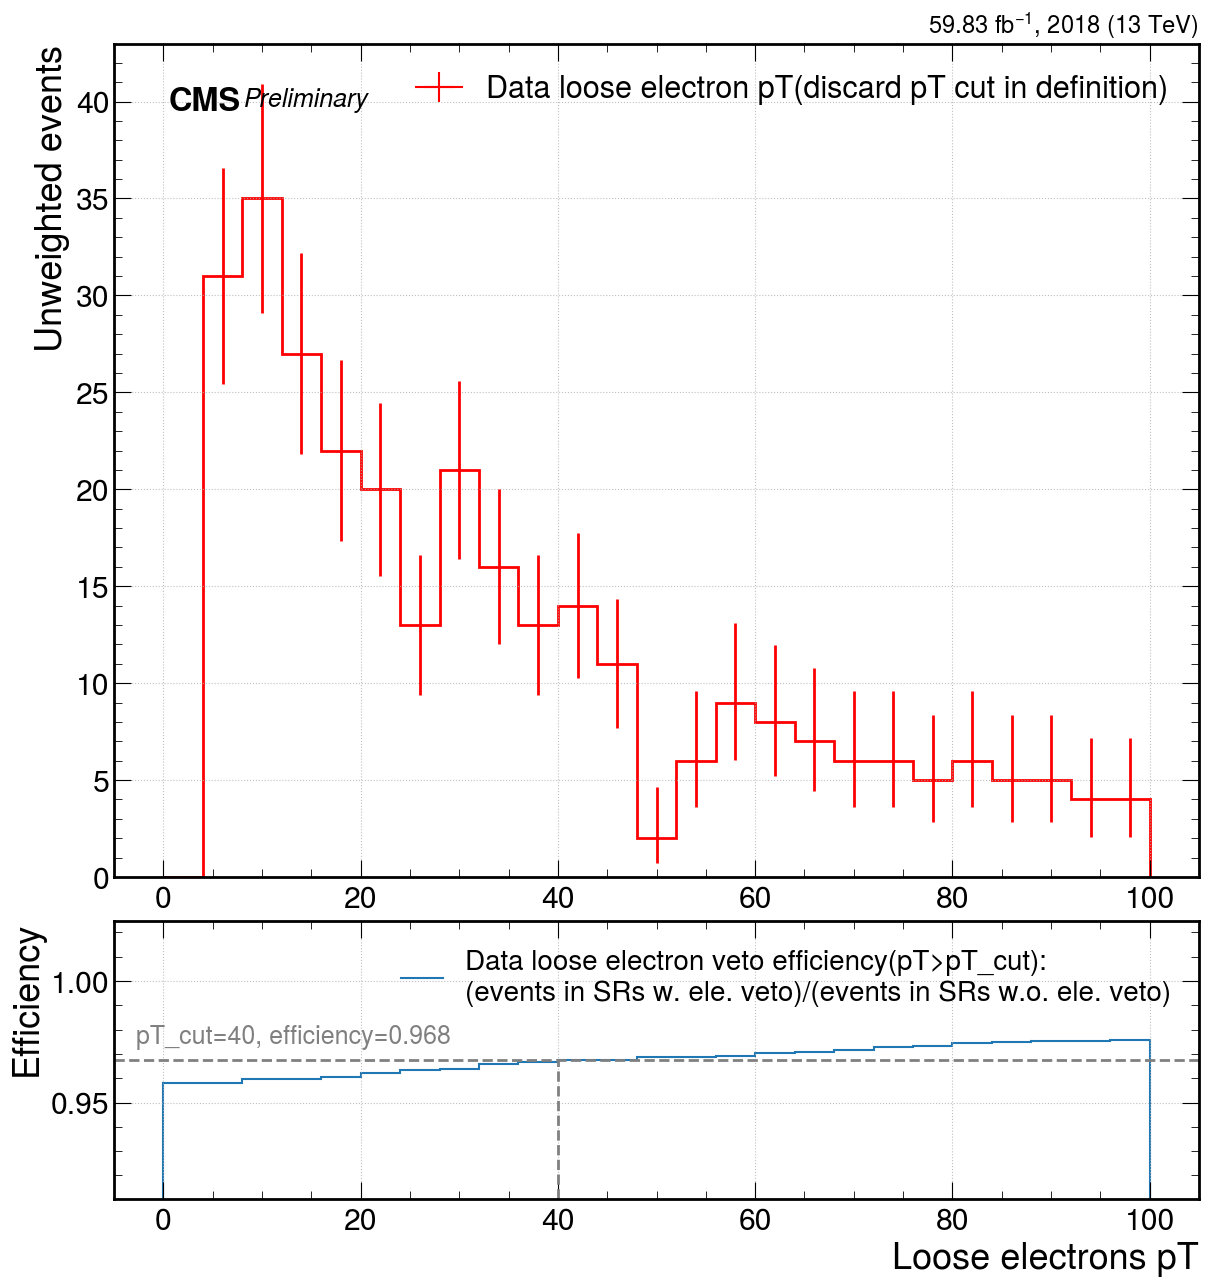

In [105]:
# plot loose ele distribution
nbins = 25
x_min = 0
x_max = 100
legend_location='upper left'
plt.rcParams['axes.prop_cycle'] = cycler(color=["tab:blue",	"tab:orange",	"tab:green",	"tab:red",	"tab:purple", "tab:brown", "tab:pink", "k","tab:olive" ,	"tab:cyan"])
# plt.figure(figsize=(14,10))
f = plt.figure(figsize=(14, 15))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax = f.add_subplot(gs[0])
plt.grid()
LUMI = {"2016": 36.33, "2017": 41.48, "2018": 59.83,"Full-Run2":138}
hep.cms.label(loc = 1, data=True, year=year, ax=ax, lumi=LUMI[year], fontsize=18, llabel='Preliminary')
ax1 = f.add_subplot(gs[1])
ax1.grid()

#plot pT distribution first
hist_region = bh.Histogram(bh.axis.Regular(nbins, x_min, x_max), storage=bh.storage.Weight())
hist_region.fill(loose_ele_pt)
hist_value_up = flow(hist_region)[0]
hist_var_up   = flow(hist_region)[1]
err_up = np.nan_to_num(error_bar(hist_value_up, hist_var_up, type = "mc"), nan = 0)
hep.histplot(hist_value_up, bins=hist_region.axes[0].edges, yerr=err_up, label=f"{sample} loose electron pT(discard pT cut in definition)", histtype='step', stack=False, linewidth=2, ax=ax, color = "red")

#then plot pT cut efficiency
hep.histplot(efficiency_loose, bins=hist_region.axes[0].edges,ax = ax1, label=f"{sample} loose electron veto efficiency(pT>pT_cut):\n(events in SRs w. ele. veto)/(events in SRs w.o. ele. veto)")

ax1.plot([40,40],[0.95*ak.min(efficiency_loose), efficiency_loose[10]], linestyle="dashed", lw=2, color='gray')
# ax1.plot([ax1.get_xlim()[0],ax1.get_xlim()[1]], [efficiency_good[10],efficiency_good[10]], linestyle="dashed", lw=2, color='gray')    
ax1.axhline(y=efficiency_loose[10], xmin=0, xmax=1, linestyle="dashed", lw=2, color='gray')
# ax.set_xlabel("Good electrons pT")
ax.set_ylabel("Unweighted events")

ax1.set_xlabel("Loose electrons pT")
ax1.set_ylabel("Efficiency")
ax1.text(0.02,-0.2,f"pT_cut=40, efficiency={str(round(efficiency_loose[10],3))}",fontsize=18, color="gray", ha='left',transform=ax.transAxes)
# (efficiency_good[10]/100)*0.5
ax1.set_ylim(0.95*ak.min(efficiency_loose), 1.05*ak.max(efficiency_loose))
# ax.set_yscale('log') 
ax.legend(loc="upper right", ncol=1, frameon=False, fontsize=22)
ax1.legend(loc="upper right", ncol=1, frameon=False, fontsize=20)

plt.savefig(f"{plot_dir}/loose_ele_pT_{year}_{sample}.pdf", bbox_inches='tight')    


### veto all ele

In [106]:
selection = PackedSelection() #initialize a new object
signGenWeights = None if isData else np.sign(filtered_events["genWeight"]) #get genWeight sign, because only the sign matters
n_events = len(filtered_events) if isData else int(np.sum(signGenWeights)) #events number for MC events should be the sum of "sign"
selection = PackedSelection() #initialize a new object

cutflow = {}
# cutflow["all"] = len(events) #shouldn't be n_events?
cutflow["all"] = n_events

#veto (mini-)isolated muons
#referring to : https://github.com/farakiko/boostedhiggs/blob/ec53b97857bf64aa4d75f639e290181e65a55b4c/boostedhiggs/hwwprocessor.py#L185-L237
muons = ak.with_field(filtered_events.Muon, 0, "flavor")
electrons = ak.with_field(filtered_events.Electron, 1, "flavor")

# muons: already required when doing ntuple files
loose_muons = (
    (((muons.pt > 30) & (muons.pfRelIso04_all < 0.25)) | (muons.pt > 55))
    & (np.abs(muons.eta) < 2.4)
    & (muons.looseId)
)

n_loose_muons = ak.sum(loose_muons, axis=1)
good_muons = (
    (muons.pt > 30)
    & (np.abs(muons.eta) < 2.4)
    & (np.abs(muons.dz) < 0.1)
    & (np.abs(muons.dxy) < 0.05)
    & (muons.sip3d <= 4.0)
    & muons.mediumId
)
n_good_muons = ak.sum(good_muons, axis=1)


# electrons
loose_electrons = (
    (((electrons.pt > 38) & (electrons.pfRelIso03_all < 0.25)) | (electrons.pt > 120))
    & (np.abs(electrons.eta) < 2.5)
    & ((np.abs(electrons.eta) < 1.44) | (np.abs(electrons.eta) > 1.57))
    # & (electrons.cutBased >= 2)
    & (electrons.mvaFall17V2noIso_WPL)
    # & (electrons.cutBased >= electrons.LOOSE) #cut-based ID Fall17 V2 (0:fail, 1:veto, 2:loose, 3:medium, 4:tight)
)
n_loose_electrons = ak.sum(loose_electrons, axis=1)
good_electrons = (
    (((electrons.pt > 38) & (electrons.pfRelIso03_all < 0.15)) | (electrons.pt > 120))
    & (np.abs(electrons.eta) < 2.5)
    & ((np.abs(electrons.eta) < 1.44) | (np.abs(electrons.eta) > 1.57))
    & (np.abs(electrons.dz) < 0.1)
    & (np.abs(electrons.dxy) < 0.05)
    & (electrons.sip3d <= 4.0)
    & (electrons.mvaFall17V2noIso_WP90)
)
n_good_electrons = ak.sum(good_electrons, axis=1)

# n_leptons = n_loose_electrons + n_good_electrons + n_loose_muons + n_good_muons
n_leptons = n_loose_electrons + n_good_electrons 

preselection_cut_4 = pad_val(
        (n_leptons == 0) , #mass and pT cut of each jet in event
        len(filtered_events), #pad to num_jets length
        False,  #pad with value False
        )

add_selection(
    "no (mini-)isolated leptons", #string name
    preselection_cut_4.astype(bool), #selection content
    selection, #PackedSelection object
    cutflow, #cut-flow dict, storing events number after each cut
    isData,
    signGenWeights,#sum the signGenWeights for events which pass the selection
)


In [107]:
cutflow

{'all': 4329, 'no (mini-)isolated leptons': 4187}

In [108]:
data_points.append(cutflow["all"])
data_points.append(cutflow["no (mini-)isolated leptons"])

In [109]:
electron_eff =  (cutflow["all"] - cutflow['no (mini-)isolated leptons'])/cutflow["all"]

In [110]:
electron_eff

0.0328020328020328

In [111]:
#making plots:

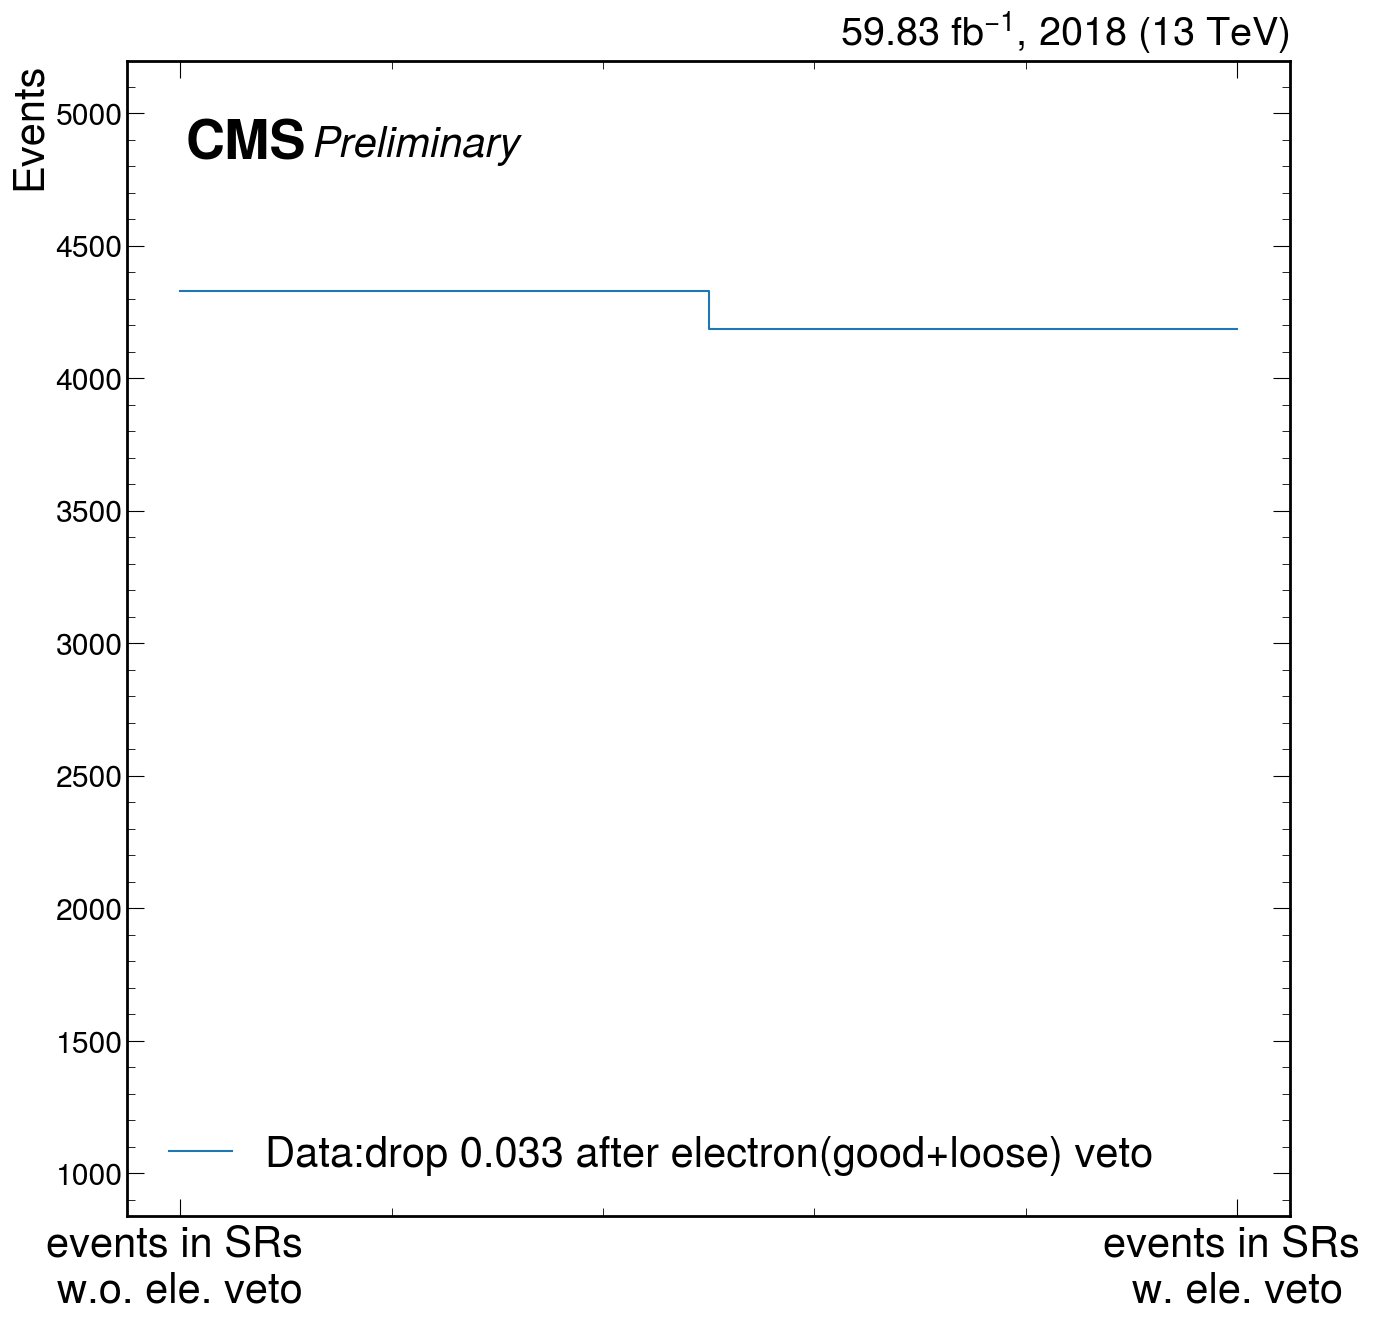

In [112]:
import matplotlib.pyplot as plt
import mplhep as hep

# 数据点和标签
labels = ['events in SRs \nw.o. ele. veto', "events in SRs \nw. ele. veto"]


# 创建阶梯状图
LUMI = {"2016": 36.33, "2017": 41.48, "2018": 59.83,"Full-Run2":138}
fig, ax = plt.subplots(figsize = (15,15))
ax.step(range(len(data_points)), data_points, where='mid', label=f"{sample}:drop {str(round(electron_eff,3))} after electron(good+loose) veto")
# ax.step(range(len(data_points)), data_points, where='mid')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize = 30)
hep.cms.label(loc = 1, data=isData, year=year, ax=ax, lumi=LUMI[year], fontsize=30, llabel='Preliminary')
# ax.set_xticklabels(labels, fontsize=14, ha='center', va='top', rotation=0, linespacing=1.5)

# for i in range(len(data_points)):
#     ax.text(i, data_points[i], labels[i], ha='center', va='bottom')

# 添加标签和标题
# ax.set_xlabel('Labels')
ax.set_ylim(data_points[-1]*0.2,data_points[0]*1.2)
ax.set_ylabel('Events',fontsize = 30)
# ax.set_title('Events number after each cut',fontsize = 30)
ax.legend(loc = "lower left",fontsize = 30)

# 如果你想使用HEP样式
hep.style.use("CMS")
plt.savefig(f"{plot_dir}/{sample}.pdf")
# 显示图形
plt.show()


### example code from the contact

In [2]:
import numpy as np

# Set seed for reproducibility
np.random.seed(12345)

# Parameters
num_events = 10000000  # Total number of events to simulate
prob_1e = 1/3       # Probability of one electron
prob_0e = 1-prob_1e       # Probability of zero electrons
eff_data = 0.9      # Efficiency of electron passing identification in data
eff_MC = 0.95        # Efficiency of electron passing identification in simulation

# Simulate the truth number of electrons for each event
electron_counts = np.random.choice([0, 1], size=num_events, p=[prob_0e, prob_1e])

# Simulate whether the electron passes the identification in data and simulation
passes_data = np.random.rand(num_events) < eff_data
passes_MC = np.random.rand(num_events) < eff_MC

# Determine events with no identified electrons in data and simulation
no_identified_data = (electron_counts == 0) | ((electron_counts == 1) & ~passes_data)
no_identified_MC = (electron_counts == 0) | ((electron_counts == 1) & ~passes_MC)

# Calculate the probabilities
P_0 = np.mean(electron_counts == 0)
P_1 = np.mean(electron_counts == 1)
P_no_identified_data = np.mean(no_identified_data)
P_no_identified_MC = np.mean(no_identified_MC)

# Calculate the correction factor
C = (P_0 + P_1 * (1 - eff_data)) / (P_0 + P_1 * (1 - eff_MC))

# Correct the simulated MC events
corrected_no_identified_MC = np.mean(no_identified_MC) * C

# Output the results
print(f"P_0 (Simulated): {P_0}")
print(f"P_1 (Simulated): {P_1}")
print(f"P_no_identified_data (True): {P_no_identified_data}")
print(f"P_no_identified_MC (Uncorrected): {P_no_identified_MC}")
print(f"C: {C}")
print(f"P_no_identified_MC (Corrected): {corrected_no_identified_MC}")
print(f"Difference after correction: {abs(P_no_identified_data - corrected_no_identified_MC)}")


P_0 (Simulated): 0.6663871
P_1 (Simulated): 0.3336129
P_no_identified_data (True): 0.6998287
P_no_identified_MC (Uncorrected): 0.6831265
C: 1.024420191294496
P_no_identified_MC (Corrected): 0.6998085798083394
Difference after correction: 2.0120191660533138e-05
